# Soluciones Integrales para la Colocación de Pozos en OilyGiant

# DESCRIPCIÓN. 

En la compañia  de extracción de petróleo OilyGiant ha iniciado un proyecto en la cual es identificar las mejores ubicaciones y la más optímas para poder abrir **200** nuevos pozos. Este proyecto se basará en el análisis de datos geológicos de tres regiones diferentes, con la finalidad de maximizar el volumen de reservas, y en última instancia, el beneficio total. 

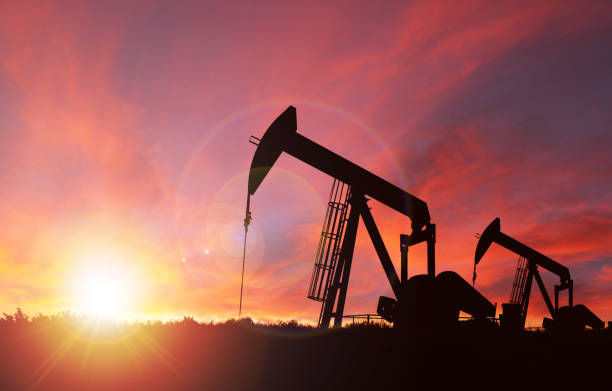

# DIRECCIÓN DE LOS DATOS. 

Para este proyecto, se trabajará con tres archivos de datos que contienen información de exploración geológica de las regiones seleccionadas. Los archivos son:
- '`geo_data_0.csv`'
- '`geo_data_1.csv`'
- '`geo_data_2.csv`'

Cada uno de estos conjuntos de datos incluye las siguientes columnas:
- '`id`':  Identificador único de pozo de petróleo, que permite distinguir cada pozo en el análisis.
- '`f0, f1, f2`': Tres características geológicas de los puntos de exploración. Aunque el significado específico de cada característica no es crucial para el análisis, su relevancia radica en su capacidad para influir en el volumen de reservas estimadas.
- '`product`': Volumen de reservas en el pozo de petróleo, expresado en miles de barriles. Este dato es fundamental para la evaluación de la viabilidad económica de cada pozo y para la toma de decisiones estratégicas en el desarrollo de nuevos pozos.


# CONDICCIONES DEL PROYECTO

- **Método de Entrenamiento**: Se utilizará exclusivamente la regresión lineal para el entrenamiento del modelo.

- **Estudio de Exploración**: Durante la exploración de la región, se llevará a cabo un estudio de 500 puntos, de los cuales se seleccionarán los mejores 200 para el cálculo del beneficio.

- **Presupuesto**: El presupuesto destinado para el desarrollo de los 200 pozos petroleros es de 100 millones de dólares.

- **Generación de Ingresos** : Un barril de materias primas genera 4.5 USD de ingresos. Además, el ingreso por unidad de producto se estima en 4500 dólares (el volumen de reservas está expresado en miles de barriles).

- **Evaluación de Riesgos**: Tras la evaluación de riesgo, se mantendrán únicamente las regiones con un riesgo de pérdidas inferior al 2.5%. Entre las que cumplan con este criterio, se seleccionará la región con el beneficio promedio más alto.

- **Datos Sintéticos**: Es importante mencionar que los datos utilizados son sintéticos, lo que significa que los detalles del contrato y las características del pozo no se han publicado.

## PREPARACIÓN DE LOS DATOS

### INICIALIZACIÓN

In [1]:
# Cargar todas las librerías a usar en el proyecto. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Importar la función de la Regresión Linear
from sklearn.linear_model import LinearRegression

#Imporarta la función de cálculo del MAPE desde la librería de scikit-learn 
from sklearn.metrics import mean_absolute_error

# Importa la función de cálculo del EMC desde la librería scikit-learn
from sklearn.metrics import mean_squared_error


# Importar la función train_test_split desde la librería sklearn 
from sklearn.model_selection import train_test_split

### CARGAR LOS DATOS. 

In [2]:
# Cargar los archivos 
geo0 = pd.read_csv('/datasets/geo_data_0.csv')
geo1 = pd.read_csv('/datasets/geo_data_1.csv')
geo2 = pd.read_csv('/datasets/geo_data_2.csv')

### ANÁLISIS DE LOS DATOS. 


#### ANÁLISIS DE LA BASE DE DATOS DE GEO0

In [3]:
#Primero se va analizar la base de datos de geo0 

geo0.info()
print()
print()
geo0.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB




,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


In [4]:
# Obtener las 10 primeras filas de las bases de datos 
geo0.head(10)

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647
5,wX4Hy,0.969570,0.489775,-0.735383,64.741541
6,tL6pL,0.645075,0.530656,1.780266,49.055285
7,BYPU6,-0.400648,0.808337,-5.624670,72.943292
8,j9Oui,0.643105,-0.551583,2.372141,113.356160
9,OLuZU,2.173381,0.563698,9.441852,127.910945


In [5]:
#Obtener la dimensión del DataFrame

geo0.shape

(100000, 5)

In [6]:
#Verificación de que no haya duplicado. 

duplicados0= geo0.duplicated().sum()
print(f'Se encontro que hay: {duplicados0} duplicados en el DataFrame de Geo 0')

Se encontro que hay: 0 duplicados en el DataFrame de Geo 0


In [7]:
#comprobar los valores  ausentes 
data_mis_0 = geo0.isna().sum()
print(f'Se encontro que hay: {data_mis_0} valores ausentes en el DataFrame de Geo 0') 

Se encontro que hay: id         0
f0         0
f1         0
f2         0
product    0
dtype: int64 valores ausentes en el DataFrame de Geo 0


#### ANÁLISIS DE LA BASE DE DATOS DE GEO1

In [8]:
#Se va analizar el Data Frame de geo1

geo1.info()
print()
print()
geo1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB




,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [9]:
# Obtener las 10 primeras filas de las bases de datos 
geo1.head(10)

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305
5,HHckp,-3.327590,-2.205276,3.003647,84.038886
6,h5Ujo,-11.142655,-10.133399,4.002382,110.992147
7,muH9x,4.234715,-0.001354,2.004588,53.906522
8,YiRkx,13.355129,-0.332068,4.998647,134.766305
9,jG6Gi,1.069227,-11.025667,4.997844,137.945408


In [10]:
#Obtener la dimensión del DataFrame

geo1.shape

(100000, 5)

In [11]:
#Verificación de que no haya duplicado. 

duplicados1= geo1.duplicated().sum()
print(f'Se encontro que hay: {duplicados1} duplicados en el DataFrame de Geo 1')

Se encontro que hay: 0 duplicados en el DataFrame de Geo 1


In [12]:
#comprobar los valores  ausentes 
data_mis_1 = geo1.isna().sum()
print(f'Se encontro que hay: {data_mis_1} valores ausentes en el DataFrame de Geo 1') 

Se encontro que hay: id         0
f0         0
f1         0
f2         0
product    0
dtype: int64 valores ausentes en el DataFrame de Geo 1


#### ANÁLISIS DE LA BASE DE DATOS DE GEO2

In [13]:
#Se va analizar el Data Frame de geo2

geo2.info()
print()
print()
geo2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB




,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [14]:
# Obtener las 10 primeras filas de las bases de datos 
geo2.head(10)

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746
5,LzZXx,-0.758092,0.710691,2.585887,90.222465
6,WBHRv,-0.574891,0.317727,1.773745,45.641478
7,XO8fn,-1.906649,-2.458350,-0.177097,72.480640
8,ybmQ5,1.776292,-0.279356,3.004156,106.616832
9,OilcN,-1.214452,-0.439314,5.922514,52.954532


In [15]:
#Obtener la dimensión del DataFrame

geo2.shape

(100000, 5)

In [16]:
#Verificación de que no haya duplicado. 

duplicados2= geo2.duplicated().sum()
print(f'Se encontro que hay: {duplicados2} duplicados en el DataFrame de Geo 2')

Se encontro que hay: 0 duplicados en el DataFrame de Geo 2


In [17]:
#comprobar los valores  ausentes 
data_mis_2 = geo2.isna().sum()
print(f'Se encontro que hay: {data_mis_2} valores ausentes en el DataFrame de Geo 2') 

Se encontro que hay: id         0
f0         0
f1         0
f2         0
product    0
dtype: int64 valores ausentes en el DataFrame de Geo 2


#### CONCLUSIONES DEL ANÁLISIS

Con el análisis que se realizó se pudo observar que la base de datos de `geo0`, `geo1` y `geo2` no tienen datos nulos ni duplicados. 

## ENTRENAMIENTO Y PRUEBA DEL MODELO POR REGIÓN.  

In [18]:
#2.1 DIVISIÓN DE LOS DATOS EN UN CONJUNTO DE ENTRENAMIENTO Y UN CONJUNTO DE VALIDACIÓN EN UNA PROPORCIÓN 75:25.
actual_state = np.random.RandomState(54321)
def train(data, random_state = actual_state):
    # extrae las características
    features = data.drop(columns=['product', 'id'])
    # extrae los objetivos
    target= data['product']
    
    # segmentar el 25% de los datos para hacer el conjunto de validación
    features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345)
    
#2.2 ENTRENAMIENTO DEL MODELO Y GENERACIÓN DEL MODELO Y GENERACIÓN DE PREDICCIÓN PARA EL CONJUNTO DE VALIDACIÓN.  
    #Iniciar el constructor de modelos 
    model= LinearRegression()
    #Entrenar el modelo en el conjunto de entrenamiento
    model.fit(features_train, target_train)
    # Obtención de  las predicciones del modelo en el conjunto de validación
    predictions_valid = model.predict(features_valid) 
    
#2.3 MOSTRAR EL VOLUMEN MEDIO DE RESERVAS OBJETIVA Y  PREDICHAS, Y TAMBIÉN EL RMSE DEL MODELO. 

    # Calcular el RECM en el conjunto de validación
    rmse = mean_squared_error(target_valid, predictions_valid, squared= False)
    #Calcularla media del objetivo del producto
    mean_target = target.mean()
    # Calcular la media de predicciones del productos
    mean_predictions = predictions_valid.mean()
   
    

    #Retornar los resultados de los cálculos para su análsis en este punto
    # También se va a retornar los conjuntos de entrenamiento y validación para uso posterior. 
    return rmse, mean_target, mean_predictions, target_valid, predictions_valid

    
# 2.4 DEMOSTRACIÓN DE LOS RESULTADOS EN CADA REGIÓN 
print('Los resultados obtenidos por cada región son las siguientes:')

print("________________________________________________________________")
print()
print('Los resultados obtenidos para la Región 0:')
rmse_0, mean_target_0, mean_predictions_0, target_valid_0, predictions_valid_0= train(geo0)

print(f'El valor obtenido de RMSE es de: {rmse_0 :.2f}')
print(f'Volumen medio objetivo en la región es de: {mean_target_0 :.2f}')
print(f'Volumen medio predicho de reservas en la región es de: {mean_predictions_0 :.2f}')


print("________________________________________________________________")
print('Los resultados obtenidos para la Región 1:')
rmse_1, mean_target_1, mean_predictions_1, target_valid_1, predictions_valid_1= train(geo1)

print(f'El valor obtenido de RMSE es de: {rmse_1 :.2f}')
print(f'Volumen medio objetivo en la región es de: {mean_target_1 :.2f}')
print(f'Volumen medio predicho de reservas en la región es de: {mean_predictions_1 :.2f}')


print("________________________________________________________________")
print('Los resultados obtenidos para la Región 2:')
rmse_2, mean_target_2, mean_predictions_2, target_valid_2, predictions_valid_2= train(geo2)

print(f'El valor obtenido de RMSE es de: {rmse_2 :.2f}')
print(f'Volumen medio objetivo en la región es de: {mean_target_2 :.2f}')
print(f'Volumen medio predicho de reservas en la región es de: {mean_predictions_2 :.2f}')

Los resultados obtenidos por cada región son las siguientes:
________________________________________________________________

Los resultados obtenidos para la Región 0:
El valor obtenido de RMSE es de: 37.58
Volumen medio objetivo en la región es de: 92.50
Volumen medio predicho de reservas en la región es de: 92.59
________________________________________________________________
Los resultados obtenidos para la Región 1:
El valor obtenido de RMSE es de: 0.89
Volumen medio objetivo en la región es de: 68.83
Volumen medio predicho de reservas en la región es de: 68.73
________________________________________________________________
Los resultados obtenidos para la Región 2:
El valor obtenido de RMSE es de: 40.03
Volumen medio objetivo en la región es de: 95.00
Volumen medio predicho de reservas en la región es de: 94.97


# 2.5 CONCLUSIÓN 

Los resultados obtenidos con la Regresión Lineal muestran los siguientes aspectos:

* La  **Región** 2 tuvo el mayor volumen medio objetivo, es decir, la mayor cantidad de reservas reales, y también el mayor volumen medio predicho por el modelo. Pero presentó un RMSE mayor que las otras regiones. 
* La **Región 1** presentó el menor RMSE, lo que indica que las predicciones en esta región fueron las más precisas, aunque fue la región con el menor volumen tanto en términos de reservas reales como predichas.
* En el caso de la **Región 0** mostró resultados intermedios tanto en términos de volumen medio objetivo como en predicciones, y su RMSE se sitúa entre las otras dos regiones. Esto indica que el modelo tiene un comportamiento consistente, pero quizás puede optimizarse para mejorar aún más la precisión en esta región.


## PREPARACIÓN PARA EL CÁLCULO DE GANANCIAS.

### ALMACENAMIENTO DE LOS VALORES NECESARIOS PARA LOS CÁLCULOS EN VARIABLES SEPARADAS. 

In [19]:
#CONDICIONES INICIALES. 
sample_size = 500 # Tamaño de la muestra
budget = 100000000 # Presupuesto total
cost_per_point = 500000 # Costo medio por pozo petrolífero
product_price = 4500 # Precio por barril 
risk = 0.025 # Riesgo de pérdidas 
points_per_budget = budget // cost_per_point
print('Los puntos que se pueden perforar son', points_per_budget)

Los puntos que se pueden perforar son 200


### CALCULAR EL VOLUMEN DE RESERVAS DE PETRÓLEO EN CANTIDAD PARA EL DESARROLLO DE NUEVOS POZOS. 

In [20]:
def cal_income(predictions_valid, target_valid):
    # Convertir a Series de pandas para usar reset_index
    predictions_valid = pd.Series(predictions_valid).reset_index(drop=True)
    target_valid = pd.Series(target_valid).reset_index(drop=True)
    
    # Ordenar las predicciones de forma descendente y seleccionar las mejores según el presupuesto
    st = predictions_valid.sort_values(ascending=False).head(points_per_budget)
    
    # Seleccionar las reservas correspondientes a las predicciones seleccionadas
    best = target_valid.iloc[st.index]
    best = pd.DataFrame(best, columns=['product'])
    
    # Calcular los ingresos multiplicando el precio por la cantidad del producto
    best['income'] = best['product'].multiply(product_price)
    
    # Sumar el total de los ingresos 
    total_income = best['income'].sum() 
    
    
    return best, total_income

In [21]:
best_0, total_income_0 = cal_income(predictions_valid_0, target_valid_0)
print(f'Las ganancias para los {points_per_budget} mejores pozos de la región 0 sería de: {total_income_0 - budget :.2f} USD')

Las ganancias para los 200 mejores pozos de la región 0 sería de: 33208260.43 USD


In [22]:
best_1, total_income_1 = cal_income(predictions_valid_1, target_valid_1)
print(f'Las ganancias para los {points_per_budget} mejores pozos de la región 1 sería de: {total_income_1 - budget :.2f} USD')

Las ganancias para los 200 mejores pozos de la región 1 sería de: 24150866.97 USD


In [23]:
best_2, total_income_2 = cal_income(predictions_valid_2, target_valid_2)
print(f'Las ganancias para los {points_per_budget} mejores pozos de la región 2 sería de: {total_income_2 - budget :.2f} USD')

Las ganancias para los 200 mejores pozos de la región 2 sería de: 27103499.64 USD


### CONCLUSIÓN DEL ANÁLISIS DE LAS GANANCIAS. 

Con base a los resultados que se obtuvieron en el calculo de las ganancias de las mejores perforaciones en las tres regiones estudiadas, se pudo observar lo siguiente: 
* En el caso de la **Región 0** se logro observar que se obtuvo una ganancia proyectada para los 200 pozos más rentables de aproximadamente de 33,208,260 USD. Cabe mencionar que se desconto el presupuesto inicial destinado para los pozos. En este se puede apreciar que de los tres, este representa el que tiene mayor ganancias. Lo que nos indica que tiene una gran rentabilidad en comparación con el coto de inversión 
* En el caso de la **Región 1** se logro apreciar una ganancia proyectada para los 200 pozos más rentables de aproximente de 24,150,867 USD. También como en caso de la **Región 0** se desconto el presupuesto inicial. Aunque en esta región se generan beneficios, su rentabilidad que tiene es menor que la **Región 0** y la **Región 2**. 
* En el caso de la **Región 2** se logro apreciar una ganancia proyectada para los 200 pozos más rentables de aproximadamente de 27,103,500 USD. Este obtuvo una mayor ganancia que la **Región 1**, pero este sigue siendo inferior a las ganancias de la **Región 0** 

En general, la **Región 0** se presenta como la más rentable para realizar las perforaciones, ya que ofrece la mayor ganancia neta después de descontar el presupuesto asignado. Por lo tanto, si el objetivo es maximizar las ganancias, la **Región 0** debería ser priorizada para la inversión en perforación de pozos.

## CALCULAR LOS RIESGOS

En este punto se utilizará la técnica del bootstrapping con 1000 muestras para hallar la distribución de los beneficios y se obtendra el beneficio promedio de cada región.

In [24]:
def bootstrapping(predictions_valid, target_valid):
    state = np.random.RandomState(12345)
    values= []
    
     # Paso 1: Asegurarse de que los índices estén alineados
    target_valid =pd.Series(target_valid).reset_index(drop=True)
    
    for i in range(1000):
        #Paso 2: Tomar una muestra del target con reemplazo
        target_subsample = target_valid.sample(n=sample_size, replace=True, random_state=state)
        #Paso 3: Obtener las predicciones correspondientes a los índices de la muestra
        probs_subsample = predictions_valid[target_subsample.index]
        
         # Paso 4: Calcular ingresos totales
        total_income = cal_income(probs_subsample, target_subsample)[1]
        
        # Paso 5: Calcular ingreso neto
        revenue = total_income - budget
        values.append(revenue)
        
    values = pd.Series(values)
    
    mean = values.mean()
    lower = values.quantile(0.05) 
    upper = values.quantile(0.95)
    
    
    # Paso 6: Calcular la probabilidad de pérdida
    probability_of_lose = (values < 0).mean()
    risk = probability_of_lose * 100
    
    # Paso 7: Calcular el RMSE 
    error = mean_squared_error(target_valid, predictions_valid, squared= False)
    mape =  mean_absolute_error(target_valid, predictions_valid)
    
    print(f'El Benenficio medio es de: {mean :.2f}')
    print(f'El intervalo de confianza del 95% es de ({lower :.2f} , {upper :.2f})')
    print(f'El riesgo de perdida es de {risk :.2f}%')
    print(f'El valor obtenido de RMSE es de: {error :.2f}')
    print(f'El valor obtenido del error de porcentaje medio absoluto es de: {mape : .2f}%')

In [25]:
bootstrapping(predictions_valid_0, target_valid_0)

El Benenficio medio es de: 3961649.85
El intervalo de confianza del 95% es de (-371815.96 , 8426881.61)
El riesgo de perdida es de 6.90%
El valor obtenido de RMSE es de: 37.58
El valor obtenido del error de porcentaje medio absoluto es de:  30.92%


In [26]:
bootstrapping(predictions_valid_1, target_valid_1)

El Benenficio medio es de: 4560451.06
El intervalo de confianza del 95% es de (1094757.21 , 7910055.13)
El riesgo de perdida es de 1.50%
El valor obtenido de RMSE es de: 0.89
El valor obtenido del error de porcentaje medio absoluto es de:  0.72%


In [27]:
bootstrapping(predictions_valid_2, target_valid_2)

El Benenficio medio es de: 4044038.67
El intervalo de confianza del 95% es de (-585334.41 , 8411239.97)
El riesgo de perdida es de 7.60%
El valor obtenido de RMSE es de: 40.03
El valor obtenido del error de porcentaje medio absoluto es de:  32.79%


### CONCLUSIÓN DEL ANÁLISIS DEL CÁLCULO DE LOS RIESGO

Con base en los resultados obtenidos al calcular los riesgo de perdida en  las mejores perforaciones en las tres regiones estudiadas, se puede observar lo siguiente:

*En el caso de la **Región 0** se pudo observar lo siguiente:* 
  * Se pudo observar qie el beneficio medio que se calculo fue el más bajo de las tres regiones. 
  * Obtuvo una amplia dispersión en los intervalos de confianza y un MAPE de **30.92%** nos indica que las predicciones en esta región no son del toda precisas. 
  * En el caso del riesgo de pérdida se obtuvo el **6.9%** y este no es alarmante ni insignificante. 

*En el caso de la **Región 1** se pudo observar lo siguiente:* 
  * A comparación de las otras dos regiones, este obtuvo un beneficio medio de **4560451.06**. Lo cual la hace más llamativa desde el punto de vista de la inversión y las ganancias. 
  * Al obtener un menor intervalo de confianza  y un MAPE DE **0.72%** nos indica que la predicciones son precisas. 
  * En el caso del riesgo de pérdida se obtuvo un valor de **1.5%** y este es bajo. Este no representa  un riesgo signifcativo. 
  
*En el caso de la **Región 2** se pudo observar lo siguiente:*
   * En el caso del beneficio medio esta región resulto obtener un valor mayor a la **Región 0** pero este no llega al valor que se obtuvo en la **Región 1** 
   * Obtuvo una alta dispersión en los intervalos de confianza y un MAPE del **32.79%**. Esto nos indica que las predicciones no son precisas. 
   * En esta región se obtuvo un valor mayor del riesgo de pérdida a comparación de las otras regiones. 
   
En general, la **Región 1** es la opción más sólida en el termino del beneficio medio y en la precisión obtenidas en las predicciones. Lo que sugiere que esta región es la más confiable para invertir con expectativas de rendim


## CONCLUSIÓN 


Si el objetivo principal es maximizar las ganancias, la **Región 0** se presenta como la mejor opción, ya que ofrece el mayor beneficio neto tras descontar el presupuesto asignado. Sin embargo, si la prioridad es minimizar el riesgo de pérdida y mantener un beneficio estable, la **Región 1** se muestra como la opción más equilibrada, con un riesgo bajo y una buena rentabilidad proyectada de 24,150,867 USD.